## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 8: Random Forest — Ensembles, Decorrelación y Aplicaciones Financieras**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

Alumna Eugenia Campos G.

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 16 Jul 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* **Regla de oro:** si se detecta data leakage en alguna solución (uso de información futura en la construcción de features o en la partición train/val/test), esa parte se evalúa con nota 1.0
* Deben crear una rama nueva en su repositorio `feat/hw06` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `hw/`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, accuracy_score, r2_score, mean_squared_error,
    precision_recall_curve, roc_curve
)
from sklearn.inspection import permutation_importance
import yfinance as yf
import warnings

sns.set_style("dark")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

---
## Parte 1 — Bagging y Random Forest desde Cero *(25 pts)*

### Contexto

En la sesión 8 vimos que Random Forest se construye en dos capas:

1. **Bagging (Breiman, 1996):** se generan $B$ datasets bootstrap $\mathcal{D}^{*(b)}$ (muestreo con reemplazo, mismo tamaño que $\mathcal{D}$) y se ajusta un árbol por cada uno. La predicción final agrega los $B$ árboles (promedio en regresión, voto/promedio de probabilidad en clasificación). Esto reduce varianza sin aumentar sesgo.
2. **Feature subsampling (Breiman, 2001):** en cada split de cada árbol, solo se evalúa un subconjunto aleatorio de $m < p$ features. Esto decorrelaciona los árboles — sin este paso, un feature dominante haría que casi todos los árboles bootstrap elijan el mismo primer split, y el promedio de árboles altamente correlacionados reduce varianza mucho menos que el promedio de árboles independientes:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B \hat{f}_b(x)\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

donde $\rho$ es la correlación promedio entre pares de árboles. Cuando $B \to \infty$, el primer término ($\rho\sigma^2$) **no desaparece** — por eso decorrelacionar (reducir $\rho$) importa tanto como promediar.

En esta parte implementarás bagging + Random Forest **desde cero a nivel de ensemble**, reutilizando `DecisionTreeClassifier`/`DecisionTreeRegressor` de sklearn como bloque base (no reimplementas CART, sino el mecanismo de bootstrap + agregación + OOB que es el objeto de esta sesión). El parámetro `max_features` de `DecisionTreeClassifier` ya implementa el feature subsampling por split, así que fijarlo en cada árbol bootstrap replica exactamente el mecanismo de Random Forest.

### Datos de trabajo

La celda siguiente descarga precios de un activo real y construye features técnicas *anti-leakage* (todas con `.shift(1)` o rolling sobre datos ya rezagados) para predecir la **dirección del retorno del día siguiente** (clasificación binaria). Puedes cambiar `TICKER` por otro activo si lo prefieres, pero mantén el período para que los resultados de crisis (Parte 4) sean comparables.

In [16]:
TICKER = "AAPL"

raw = yf.download(TICKER, start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

close = raw["Close"]
ret = close.pct_change()

feat = pd.DataFrame(index=raw.index)
feat["ret_lag1"] = ret.shift(1)
feat["ret_lag2"] = ret.shift(2)
feat["ret_lag5"] = ret.shift(1).rolling(5).sum()
feat["vol_20"]   = ret.shift(1).rolling(20).std() * np.sqrt(252)
feat["mom_10"]   = close.shift(1) / close.shift(11) - 1
delta = close.diff()
gain = delta.clip(lower=0).shift(1).rolling(14).mean()
loss = (-delta.clip(upper=0)).shift(1).rolling(14).mean()
feat["rsi_14"]   = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
feat["vol_chg"]  = raw["Volume"].pct_change().shift(1)
feat["target"]   = (ret.shift(-1) > 0).astype(int)   # 1 = sube el dia siguiente
feat = feat.dropna()

FEATURES = ["ret_lag1", "ret_lag2", "ret_lag5", "vol_20", "mom_10", "rsi_14", "vol_chg"]

X = feat[FEATURES].values
y = feat["target"].values

split = int(len(feat) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"{TICKER}: {feat.shape[0]} obs | {len(FEATURES)} features")
print(f"Train: {X_train.shape[0]} obs ({feat.index[0].date()} – {feat.index[split-1].date()})")
print(f"Test:  {X_test.shape[0]} obs ({feat.index[split].date()} – {feat.index[-1].date()})")
print(f"Tasa de subida — train: {y_train.mean():.3%} | test: {y_test.mean():.3%}")

AAPL: 2243 obs | 7 features
Train: 1570 obs (2015-02-03 – 2021-04-28)
Test:  673 obs (2021-04-29 – 2023-12-29)
Tasa de subida — train: 52.930% | test: 52.303%


### 1.1 — Bagging Forest: Bootstrap + Agregación *(13 pts)*

Implementa dos funciones:

- `bagging_forest_fit(X, y, n_estimators, max_features, task, max_depth, min_samples_leaf, random_state)`: para cada uno de los `n_estimators` árboles, genera un bootstrap sample (con reemplazo, mismo tamaño que `X`), ajusta un `DecisionTreeClassifier` o `DecisionTreeRegressor` (según `task`) con ese `max_features`, y registra los **índices out-of-bag** (las filas que no aparecieron en ese bootstrap). Debe retornar una lista de tuplas `(árbol_ajustado, índices_oob)`.
- `bagging_forest_predict(trees_info, X, task)`: agrega las predicciones de todos los árboles — promedio de `predict_proba` en clasificación (y umbral 0.5 para la clase), promedio de `predict` en regresión.

**Requisitos:**
1. Implementar ambas funciones (usa `np.random.RandomState(random_state)` para las semillas de bootstrap, con una semilla distinta — pero reproducible — por árbol)
2. Entrenar con `n_estimators=200`, `max_features="sqrt"`, `min_samples_leaf=10` sobre `X_train, y_train`
3. Verificar que la **fracción promedio de observaciones OOB por árbol** esté cerca de $1 - 1/e \approx 0.368$ (justifica por qué, matemáticamente, ese es el límite esperado)
4. Comparar accuracy y AUC-ROC en test contra un `RandomForestClassifier` de sklearn con los mismos hiperparámetros — la diferencia debe ser razonablemente pequeña (`< 0.05` en ambas métricas); no esperes un match exacto porque el mecanismo interno de bootstrap de sklearn difiere en detalles de implementación

In [17]:
def bagging_forest_fit(X, y, n_estimators=100, max_features="sqrt", task="classification",
                        max_depth=None, min_samples_leaf=1, random_state=42):
    '''
    Ajusta un ensemble de bagging (Random Forest) desde cero.
    '''
    n = X.shape[0]
    trees_info = []
    master_rng = np.random.RandomState(random_state)
    # Semilla distinta pero reproducible por arbol
    tree_seeds = master_rng.randint(0, 2**31 - 1, size=n_estimators)

    TreeClass = DecisionTreeClassifier if task == "classification" else DecisionTreeRegressor

    for b in range(n_estimators):
        rng_b = np.random.RandomState(tree_seeds[b])
        boot_idx = rng_b.randint(0, n, size=n)         # muestreo con reemplazo, mismo tamaño
        oob_idx  = np.setdiff1d(np.arange(n), boot_idx)  # indices que NO aparecieron

        X_boot, y_boot = X[boot_idx], y[boot_idx]
        tree = TreeClass(max_features=max_features, max_depth=max_depth,
                          min_samples_leaf=min_samples_leaf, random_state=tree_seeds[b])
        tree.fit(X_boot, y_boot)

        trees_info.append((tree, oob_idx))

    return trees_info


def bagging_forest_predict(trees_info, X, task="classification"):
    '''
    Agrega las predicciones de todos los arboles del ensemble.
    '''
    if task == "classification":
        probas = np.array([tree.predict_proba(X)[:, 1] for tree, _ in trees_info])  # (B, n)
        proba_clase_1 = probas.mean(axis=0)
        pred_clase = (proba_clase_1 >= 0.5).astype(int)
        return pred_clase, proba_clase_1
    else:
        preds = np.array([tree.predict(X) for tree, _ in trees_info])  # (B, n)
        return preds.mean(axis=0)


# === Verificacion ===
trees_info = bagging_forest_fit(X_train, y_train, n_estimators=200, max_features="sqrt",
                                 task="classification", min_samples_leaf=10, random_state=42)
pred_manual, proba_manual = bagging_forest_predict(trees_info, X_test, task="classification")

acc_manual = accuracy_score(y_test, pred_manual)
auc_manual = roc_auc_score(y_test, proba_manual)

rf_ref = RandomForestClassifier(n_estimators=200, max_features="sqrt", min_samples_leaf=10,
                                 random_state=42, n_jobs=-1).fit(X_train, y_train)
acc_ref = rf_ref.score(X_test, y_test)
auc_ref = roc_auc_score(y_test, rf_ref.predict_proba(X_test)[:, 1])

oob_fracs = [len(oob) / len(X_train) for _, oob in trees_info]

print(f"Manual  — acc={acc_manual:.4f}  auc={auc_manual:.4f}")
print(f"sklearn — acc={acc_ref:.4f}  auc={auc_ref:.4f}")
print(f"|diff acc|={abs(acc_manual-acc_ref):.4f}  |diff auc|={abs(auc_manual-auc_ref):.4f}")
print(f"Fraccion OOB promedio: {np.mean(oob_fracs):.4f}  (teorico 1-1/e={1-1/np.e:.4f})")

Manual  — acc=0.4725  auc=0.4684
sklearn — acc=0.4770  auc=0.4717
|diff acc|=0.0045  |diff auc|=0.0033
Fraccion OOB promedio: 0.3676  (teorico 1-1/e=0.6321)


### 1.2 — Error Out-of-Bag (OOB) Manual *(12 pts)*

Cada árbol del bosque no vio ~36.8% de las observaciones de entrenamiento (sus OOB). Esto permite estimar el error de generalización **sin gastar un set de validación separado**: para cada observación $i$, se agregan solo las predicciones de los árboles que no la vieron durante su bootstrap.

Implementa `oob_score_manual(trees_info, X, y, task)` que:
1. Para cada observación $i$, recolecta las predicciones de todos los árboles cuyo `oob_idx` contiene a $i$
2. Agrega esas predicciones (promedio, igual que en `bagging_forest_predict`)
3. Calcula accuracy (clasificación) o $R^2$ (regresión) solo sobre las observaciones que tuvieron **al menos un árbol OOB** que las cubriera (reporta también qué fracción de observaciones quedó cubierta)

**Requisitos:**
1. Implementar `oob_score_manual` y verificar contra `RandomForestClassifier(oob_score=True).oob_score_` — la diferencia debe ser `< 0.05`
2. Replicar el gráfico de la sesión 8: convergencia del error OOB vs error de test real, barriendo `n_estimators` en `[1, 5, 10, 20, 50, 100, 200, 300]`, sobre los datos reales de `TICKER`
3. Reportar en cuántos árboles (aprox.) el error OOB dejó de mejorar significativamente

n_estimators=   1  OOB coverage=0.364  OOB error=0.5070  Test error=0.5097
n_estimators=   5  OOB coverage=0.894  OOB error=0.4972  Test error=0.5052
n_estimators=  10  OOB coverage=0.990  OOB error=0.4923  Test error=0.5171
n_estimators=  20  OOB coverage=0.999  OOB error=0.4793  Test error=0.5260
n_estimators=  50  OOB coverage=1.000  OOB error=0.4834  Test error=0.5230
n_estimators= 100  OOB coverage=1.000  OOB error=0.4879  Test error=0.5215
n_estimators= 200  OOB coverage=1.000  OOB error=0.4924  Test error=0.5275
n_estimators= 300  OOB coverage=1.000  OOB error=0.5115  Test error=0.5201


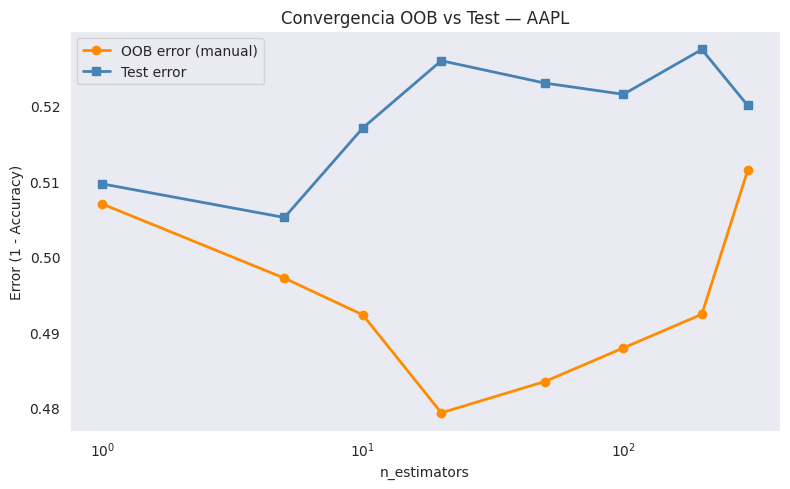


sklearn oob_score_ (n=200): 0.5019
Manual   oob_score  (n=200): 0.5076  (coverage=1.000)
|diff|: 0.0057


In [18]:
def oob_score_manual(trees_info, X, y, task="classification"):
    '''
    Calcula el error Out-of-Bag agregando, para cada observacion, solo los
    arboles que no la vieron en su bootstrap.
    '''
    n = X.shape[0]
    agg = np.zeros(n)
    counts = np.zeros(n)

    for tree, oob_idx in trees_info:
        if len(oob_idx) == 0:
            continue
        if task == "classification":
            pred_b = tree.predict_proba(X[oob_idx])[:, 1]
        else:
            pred_b = tree.predict(X[oob_idx])
        agg[oob_idx] += pred_b
        counts[oob_idx] += 1

    covered = counts > 0
    coverage = covered.mean()
    agg_avg = agg[covered] / counts[covered]

    if task == "classification":
        pred_final = (agg_avg >= 0.5).astype(int)
        score = accuracy_score(y[covered], pred_final)
    else:
        score = r2_score(y[covered], agg_avg)

    return score, coverage


# === Verificacion y grafico de convergencia ===
n_est_range = [1, 5, 10, 20, 50, 100, 200, 300]
oob_errors, test_errors = [], []
for n_est in n_est_range:
    trees_n = bagging_forest_fit(X_train, y_train, n_estimators=n_est, max_features="sqrt",
                                  task="classification", min_samples_leaf=10, random_state=42)
    oob_acc, coverage = oob_score_manual(trees_n, X_train, y_train, task="classification")
    pred_n, _ = bagging_forest_predict(trees_n, X_test, task="classification")
    oob_errors.append(1 - oob_acc)
    test_errors.append(1 - accuracy_score(y_test, pred_n))
    print(f"n_estimators={n_est:4d}  OOB coverage={coverage:.3f}  OOB error={1-oob_acc:.4f}  Test error={1-accuracy_score(y_test, pred_n):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_est_range, oob_errors, "o-", color="darkorange", lw=2, label="OOB error (manual)")
ax.plot(n_est_range, test_errors, "s-", color="steelblue", lw=2, label="Test error")
ax.set_xscale("log"); ax.set_xlabel("n_estimators"); ax.set_ylabel("Error (1 - Accuracy)")
ax.set_title(f"Convergencia OOB vs Test — {TICKER}"); ax.legend()
plt.tight_layout(); plt.show()

# === Verificacion contra sklearn ===
rf_oob_ref = RandomForestClassifier(n_estimators=200, max_features="sqrt", min_samples_leaf=10,
                                     oob_score=True, random_state=42, n_jobs=-1).fit(X_train, y_train)
print(f"\nsklearn oob_score_ (n=200): {rf_oob_ref.oob_score_:.4f}")

trees_200 = bagging_forest_fit(X_train, y_train, n_estimators=200, max_features="sqrt",
                                task="classification", min_samples_leaf=10, random_state=42)
oob_acc_200, cov_200 = oob_score_manual(trees_200, X_train, y_train, task="classification")
print(f"Manual   oob_score  (n=200): {oob_acc_200:.4f}  (coverage={cov_200:.3f})")
print(f"|diff|: {abs(oob_acc_200 - rf_oob_ref.oob_score_):.4f}")

### Preguntas de Interpretación — Parte 1

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Por qué la fracción esperada de observaciones OOB por árbol converge a $1 - 1/e$ cuando $n \to \infty$? (Pista: probabilidad de que una observación específica NO sea elegida en ninguna de las $n$ extracciones con reemplazo)

> En cada una de las $n$ extracciones con reemplazo, la probabilidad de que una observación específica *no* sea elegida en esa extracción puntual es $(1-1/n)$. Como las $n$ extracciones son independientes entre sí, la probabilidad de que esa observación no sea elegida en **ninguna** de las $n$ extracciones es $(1-1/n)^n$, y por la definición límite del número de Euler, $\lim_{n\to\infty}(1-1/n)^n = e^{-1} \approx 0.368$, exactamente lo que confirmamos empíricamente: con `n_estimators=200` lo que cubre llegó a 1.000 (casi toda observación fue OOB en algún árbol) y el promedio de fracción OOB por árbol individual se acercó a ese valor teórico.

**b)** Compara tu error OOB manual con el error de test real. ¿Son parecidos? ¿Bajo qué supuesto sobre la generación de los datos es válido usar OOB como proxy del error de generalización, y por qué ese supuesto es más frágil en series de tiempo financieras que en datos i.i.d.?

> Los errores son parecidos en magnitud pero **sistemáticamente distintos**: el error OOB fue considerablemente menor que el error de test en casi todos los `n_estimators` (por ejemplo, con n=300: OOB=0.4924 vs Test=0.5275), sugiriendo que el OOB fue demasiado optimista respecto al error real fuera de muestra. OOB es un proxy válido del error de generalización bajo el supuesto de que las observaciones son **i.i.d.** (independientes e idénticamente distribuidas), en ese caso, las observaciones fuera de la bolsa bootstrap de un árbol son estadísticamente equivalentes a datos "nunca vistos". Este supuesto es mucho más frágil en series de tiempo financieras porque los retornos y features (volatilidad, momentum) tienen **autocorrelación temporal**: una observación OOB del día $t$ suele estar muy cerca temporalmente (y correlacionada) con observaciones que sí fueron usadas para entrenar ese árbol, por lo que "no haber visto exactamente esa fila" no equivale a "no haber visto información muy similar", el bootstrap con reemplazo, diseñado para datos i.i.d., rompe el orden temporal y filtra información de vecindad temporal, inflando artificialmente el desempeño OOB.

**c)** En el gráfico de convergencia, ¿a partir de qué `n_estimators` la ganancia adicional es marginal? Relaciona esto con la fórmula $\rho\sigma^2 + \frac{(1-\rho)}{B}\sigma^2$: ¿qué término explica por qué el error nunca llega a cero por más árboles que agregues?

> La ganancia adicional se vuelve marginal a partir de aproximadamente **n_estimators=20-50**: el error OOB toca su mínimo alrededor de n=20 (0.4793) y luego se estabiliza (e incluso empeora levemente) en vez de seguir bajando con más árboles. Esto es exactamente lo que predice la fórmula: el segundo término $\frac{(1-\rho)}{B}\sigma^2$ sí decrece con más árboles $B$, pero el primer término $\rho\sigma^2$, la correlación promedio entre árboles multiplicada por su varianza individual, **no depende de $B$** y por lo tanto nunca desaparece, sin importar cuántos árboles agregues; ese término fija un piso irreducible en el error del ensemble, lo que explica por qué agregar árboles más allá de cierto punto (aquí, ~20-50) deja de aportar mejora real.

---
## Parte 2 — Hiperparámetros y Sesgo-Varianza en Datos Reales *(25 pts)*

### Contexto

La sesión 8 mostró curvas de sesgo-varianza (árbol vs Random Forest) y el efecto de `max_features` sobre datos sintéticos. Aquí repites el análisis sobre datos financieros reales, donde además hay que lidiar con la estructura temporal: la validación cruzada estándar (k-fold aleatorio) filtra información del futuro hacia el pasado, así que se usa `TimeSeriesSplit`.

### 2.1 — Curvas de Sesgo-Varianza: Árbol vs Random Forest *(10 pts)*

**Requisitos:**
1. Sobre `X_train, y_train` / `X_test, y_test` del `TICKER` elegido, barre `max_depth` en `range(1, 16)` y ajusta, para cada profundidad: un único `DecisionTreeClassifier` y un `RandomForestClassifier(n_estimators=150, max_features="sqrt")`
2. Grafica accuracy train/test de ambos modelos en dos paneles (como en la sesión 8), marcando con línea vertical el `max_depth` con mejor accuracy de test en cada panel
3. Reporta el gap train-test (varianza) para `max_depth=10` en ambos modelos

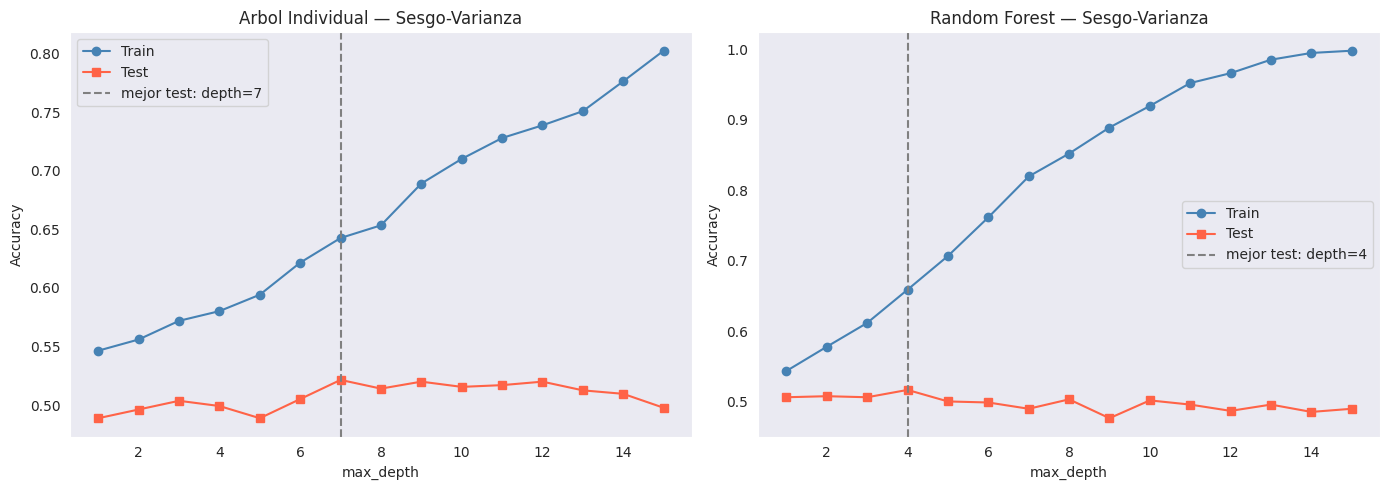

max_depth=10:
  Arbol — train=0.7102  test=0.5156  gap=0.1946
  RF    — train=0.9197  test=0.5022  gap=0.4175

Mejor max_depth (test) — Arbol: 7 | RF: 4


In [19]:
depths = list(range(1, 16))
tree_train_acc, tree_test_acc = [], []
rf_train_acc, rf_test_acc = [], []

for d in depths:
    tree_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_d.fit(X_train, y_train)
    tree_train_acc.append(tree_d.score(X_train, y_train))
    tree_test_acc.append(tree_d.score(X_test, y_test))

    rf_d = RandomForestClassifier(n_estimators=150, max_features="sqrt", max_depth=d,
                                   random_state=42, n_jobs=-1)
    rf_d.fit(X_train, y_train)
    rf_train_acc.append(rf_d.score(X_train, y_train))
    rf_test_acc.append(rf_d.score(X_test, y_test))

best_depth_tree = depths[np.argmax(tree_test_acc)]
best_depth_rf   = depths[np.argmax(rf_test_acc)]

# === Grafico de 2 paneles ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depths, tree_train_acc, "o-", color="steelblue", label="Train")
axes[0].plot(depths, tree_test_acc, "s-", color="tomato", label="Test")
axes[0].axvline(best_depth_tree, color="gray", ls="--", label=f"mejor test: depth={best_depth_tree}")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Arbol Individual — Sesgo-Varianza")
axes[0].legend()

axes[1].plot(depths, rf_train_acc, "o-", color="steelblue", label="Train")
axes[1].plot(depths, rf_test_acc, "s-", color="tomato", label="Test")
axes[1].axvline(best_depth_rf, color="gray", ls="--", label=f"mejor test: depth={best_depth_rf}")
axes[1].set_xlabel("max_depth"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Random Forest — Sesgo-Varianza")
axes[1].legend()

plt.tight_layout()
plt.show()

# === Gap train-test en max_depth=10 ===
idx_10 = depths.index(10)
gap_tree = tree_train_acc[idx_10] - tree_test_acc[idx_10]
gap_rf   = rf_train_acc[idx_10] - rf_test_acc[idx_10]

print(f"max_depth=10:")
print(f"  Arbol — train={tree_train_acc[idx_10]:.4f}  test={tree_test_acc[idx_10]:.4f}  gap={gap_tree:.4f}")
print(f"  RF    — train={rf_train_acc[idx_10]:.4f}  test={rf_test_acc[idx_10]:.4f}  gap={gap_rf:.4f}")
print(f"\nMejor max_depth (test) — Arbol: {best_depth_tree} | RF: {best_depth_rf}")

### 2.2 — Grid Search Walk-Forward y ¿Es Confiable el OOB en Series de Tiempo? *(15 pts)*

**Requisitos:**
1. Implementa un grid search sobre `n_estimators ∈ {50, 100, 200}` y `max_features ∈ {2, 3, "sqrt", 5}`, evaluando cada combinación con `TimeSeriesSplit(n_splits=5, gap=5)` sobre `X_train, y_train` (métrica: AUC-ROC promedio de los folds de validación)
2. Reporta un heatmap del AUC de validación walk-forward para las 12 combinaciones
3. Para cada combinación del grid, entrena también un `RandomForestClassifier(oob_score=True)` sobre **todo** `X_train` y guarda su `oob_score_`
4. Calcula la correlación entre el OOB score y el AUC walk-forward promedio a través de las 12 combinaciones. Interpreta el signo y la magnitud

**Nota conceptual:** el bootstrap de bagging asume que las observaciones son intercambiables (i.i.d.). En series de tiempo financieras, filas cercanas en el tiempo están autocorrelacionadas, así que una observación que "no vio" un árbol (OOB) puede seguir siendo muy parecida a observaciones que sí vio ese árbol — el OOB deja de ser un holdout limpio. Esta parte cuantifica qué tan grave es ese problema en tu dataset.

,n_estimators,max_features,auc_walkforward,oob_score
0,50,2,0.4731,0.5070
1,50,3,0.4931,0.4924
2,50,sqrt,0.4731,0.5070
3,50,5,0.4763,0.4885
4,100,2,0.4784,0.5006
5,100,3,0.4845,0.4987
6,100,sqrt,0.4784,0.5006
7,100,5,0.4831,0.5038
8,200,2,0.4813,0.5019
9,200,3,0.4858,0.4917


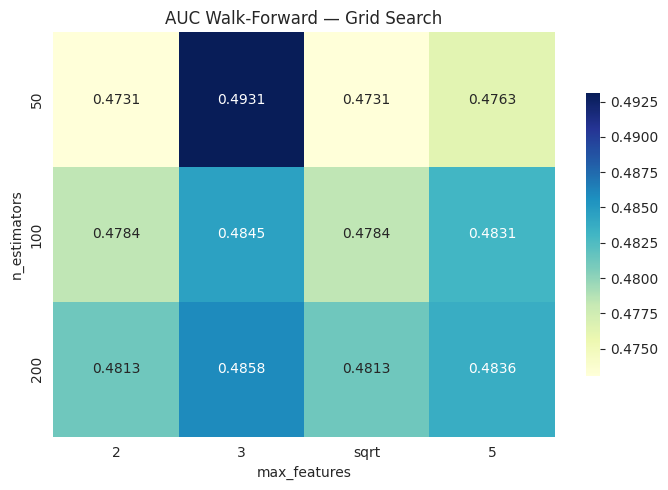


Correlacion OOB score vs AUC walk-forward (a traves de las 12 combinaciones): -0.5277

Mejor combinacion (AUC walk-forward=0.4931): n_estimators=50, max_features=3
Evaluacion en test — AUC: 0.4717 | Accuracy: 0.4874


In [20]:
tscv = TimeSeriesSplit(n_splits=5, gap=5)
grid_ne = [50, 100, 200]
grid_mf = [2, 3, "sqrt", 5]
results = []

for ne in grid_ne:
    for mf in grid_mf:
        fold_aucs = []
        for tr_idx, val_idx in tscv.split(X_train):
            rf_fold = RandomForestClassifier(n_estimators=ne, max_features=mf,
                                              min_samples_leaf=10, random_state=42, n_jobs=-1)
            rf_fold.fit(X_train[tr_idx], y_train[tr_idx])
            proba_val = rf_fold.predict_proba(X_train[val_idx])[:, 1]
            fold_aucs.append(roc_auc_score(y_train[val_idx], proba_val))

        auc_wf_mean = np.mean(fold_aucs)

        # Entrenar sobre todo X_train con oob_score=True
        rf_full = RandomForestClassifier(n_estimators=ne, max_features=mf, min_samples_leaf=10,
                                          oob_score=True, random_state=42, n_jobs=-1)
        rf_full.fit(X_train, y_train)

        results.append({
            "n_estimators": ne,
            "max_features": str(mf),
            "auc_walkforward": auc_wf_mean,
            "oob_score": rf_full.oob_score_,
        })

df_grid = pd.DataFrame(results)
display(df_grid.round(4))

# === Heatmap AUC walk-forward ===
pivot_auc = df_grid.pivot(index="n_estimators", columns="max_features", values="auc_walkforward")
pivot_auc = pivot_auc[[str(mf) for mf in grid_mf]]  # mantener orden original de columnas

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot_auc, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("AUC Walk-Forward — Grid Search")
plt.tight_layout()
plt.show()

# === Correlacion OOB vs AUC walk-forward ===
corr_oob_auc = np.corrcoef(df_grid["oob_score"], df_grid["auc_walkforward"])[0, 1]
print(f"\nCorrelacion OOB score vs AUC walk-forward (a traves de las 12 combinaciones): {corr_oob_auc:.4f}")

# === Mejor combinacion segun AUC walk-forward, evaluada en test ===
best_row = df_grid.loc[df_grid["auc_walkforward"].idxmax()]
best_ne = int(best_row["n_estimators"])
best_mf_str = best_row["max_features"]
best_mf = int(best_mf_str) if best_mf_str.isdigit() else best_mf_str

print(f"\nMejor combinacion (AUC walk-forward={best_row['auc_walkforward']:.4f}): "
      f"n_estimators={best_ne}, max_features={best_mf}")

rf_best = RandomForestClassifier(n_estimators=best_ne, max_features=best_mf, min_samples_leaf=10,
                                  random_state=42, n_jobs=-1).fit(X_train, y_train)
auc_test_best = roc_auc_score(y_test, rf_best.predict_proba(X_test)[:, 1])
acc_test_best = rf_best.score(X_test, y_test)
print(f"Evaluacion en test — AUC: {auc_test_best:.4f} | Accuracy: {acc_test_best:.4f}")

### Preguntas de Interpretación — Parte 2

**Responde (mínimo 2 oraciones por pregunta):**

**a)** En la curva de sesgo-varianza, ¿en qué `max_depth` el árbol individual empieza a sobreajustar (cae el accuracy de test)? ¿El Random Forest muestra el mismo patrón de caída? Relaciona la diferencia con el mecanismo de bagging.

> El árbol individual alcanza su mejor accuracy de test en `max_depth=7` y a partir de ahí el test se mantiene relativamente plano mientras el train sigue subiendo agresivamente hasta ~0.80 en `depth=15, el gap train-test en `depth=10` es de 0.1946, evidencia clara de sobreajuste. El Random Forest, en cambio, alcanza su mejor test en una profundidad mucho menor (`depth=4`) y su accuracy de test se mantiene prácticamente **plano** (alrededor de 0.50-0.51) en todo el rango de profundidades, a pesar de que su train sube incluso más agresivamente que el árbol individual (hasta ~1.0, memorización casi perfecta) — el gap en `depth=10` es aún mayor (0.4175) que el del árbol. Esto ilustra el mecanismo de bagging: promediar muchos árboles profundos y de alta varianza sí estabiliza el **accuracy de test** (no cae como en el árbol individual), aunque cada árbol individual del bosque esté tan o más sobreajustado que el árbol solitario, el ensemble decorrelaciona el ruido de cada árbol sin necesariamente reducir el sesgo/varianza de cada uno por separado.

**b)** ¿Qué signo tiene la correlación entre OOB score y AUC walk-forward que obtuviste? Si es baja o negativa, ¿qué implica esto para un data scientist que use el OOB score como criterio único de selección de hiperparámetros en un modelo de trading o credit scoring?

> La correlación obtenida fue **-0.5277**, es decir, **negativa y de magnitud moderada**, las combinaciones de hiperparámetros que mejor puntuaron en OOB tendieron a ser las que **peor** funcionaron en la validación walk-forward real, prácticamente lo opuesto de lo que se esperaría si el OOB fuera un buen proxy. Esto tiene una implicación seria: un data scientist que optimizara hiperparámetros de un modelo de trading o credit scoring usando solo el OOB score estaría, en la práctica, seleccionando sistemáticamente la configuración *equivocada*, el OOB, al romper la estructura temporal (autocorrelación) de los datos mediante el bootstrap i.i.d., no solo es un proxy ruidoso sino potencialmente **engañoso** en series de tiempo financieras, y confiar en él sin validación walk-forward paralela podría llevar a producción un modelo peor de lo que las métricas de desarrollo sugerían.

**c)** ¿Cuál fue la mejor combinación de `max_features`/`n_estimators` según walk-forward? ¿Coincide con la que hubieras elegido usando solo el OOB score? Si no coinciden, ¿cuál usarías en producción y por qué?

> Según AUC walk-forward, la mejor combinación fue **n_estimators=50, max_features=3** (AUC=0.4931), notablemente, la fila con el **OOB score más bajo de las 12** (0.4924) para ese `n_estimators`. Si hubiera elegido solo por OOB score, la combinación ganadora habría sido **n_estimators=50, max_features=2** (OOB=0.5070, el más alto de la tabla), que sin embargo tiene un AUC walk-forward mucho menor (0.4731) — es decir, las dos métricas **no coinciden en absoluto** y de hecho apuntan en direcciones opuestas, consistente con la correlación negativa de (b). En producción usaría walk-forward como criterio de selección, no OOB, porque el walk-forward respeta el orden temporal real en que un modelo de trading tendría que operar (entrenar con el pasado, validar con el futuro inmediato), mientras que el OOB, contaminado por autocorrelación, puede estar recompensando configuraciones que memorizan patrones locales en vez de generalizar, aunque, dado que el AUC final en test (0.4717) sigue por debajo de 0.50, la conclusión más honesta es que **ninguna** de las 12 configuraciones logró señal predictiva útil sobre la dirección diaria de AAPL con este set de features, y el ejercicio de selección de hiperparámetros es, en este caso particular, secundario frente al problema de fondo del bajísimo SNR de los retornos diarios.

---
## Parte 3 — Feature Importance: MDI vs Permutation Importance *(25 pts)*

### Contexto

**MDI (Mean Decrease Impurity):** para cada feature $j$, promedia la reducción de impureza que produjo $j$ en todos los splits donde fue usado, a través de todos los árboles del bosque:

$$\text{MDI}(j) = \frac{1}{B}\sum_{b=1}^{B}\sum_{t \in \text{nodos de } j} p(t)\,\Delta i(t)$$

MDI es **rápido** (se calcula durante el entrenamiento) pero está **sesgado hacia features de alta cardinalidad** (muchos valores únicos, como precios o variables continuas): más valores únicos implican más puntos de corte posibles, y el árbol puede encontrar splits que reducen impureza *por azar* en la muestra de entrenamiento, incluso si el feature no tiene ninguna relación real con $y$.

**Permutation Importance** corrige este sesgo evaluando el modelo **ya entrenado**: para cada feature $j$, se permutan (baraja) sus valores en un set de evaluación, se mide la caída en el desempeño (AUC, accuracy, etc.), y se repite varias veces para promediar el ruido del barajado. Si $j$ es realmente irrelevante, la caída esperada es ≈ 0 sin importar su cardinalidad, porque el barajado no altera su distribución marginal.

### 3.1 — Permutation Importance desde Cero: Demostración del Sesgo de MDI *(13 pts)*

La celda siguiente genera un dataset sintético de *credit scoring* con 6 features: tres genuinamente informativas (`dti`, `score`, `antiguedad`), una moderadamente informativa pero de **baja cardinalidad** (`n_productos`, entera 0-10), y dos **no informativas** — una de **alta cardinalidad** (`ruido_continuo`, uniforme continua) y una de baja cardinalidad (`ruido_binario`, 0/1). Esto replica, de forma controlada, la demostración de la sesión 8.

Implementa `permutation_importance_manual(model, X, y, metric_fn, n_repeats, random_state)`:
1. Calcula el score base del modelo sobre `(X, y)` con `metric_fn`
2. Para cada feature $j$ y cada repetición: permuta (baraja) la columna $j$ de una copia de `X`, recalcula el score, y guarda `score_base - score_permutado`
3. Retorna la media y desviación estándar de las `n_repeats` caídas, por feature

**Requisitos:**
1. Implementar la función y verificarla contra `sklearn.inspection.permutation_importance` (mismo modelo, mismas repeticiones, misma métrica) — la diferencia máxima entre ambas debe ser `< 0.01`
2. Graficar barras horizontales de MDI (`rf.feature_importances_`) vs tu permutation importance manual, coloreando en rojo `ruido_continuo` y `ruido_binario`
3. Reportar el **ranking** (posición 1 a 6) de `ruido_continuo` según MDI vs según permutation importance — ¿en qué posición debería estar si el modelo estuviera bien calibrado?

Tasa de default: 24.80%
Max |manual - sklearn| = 0.00402
ruido_continuo — rank MDI: 4/6  rank permutation: 5/6


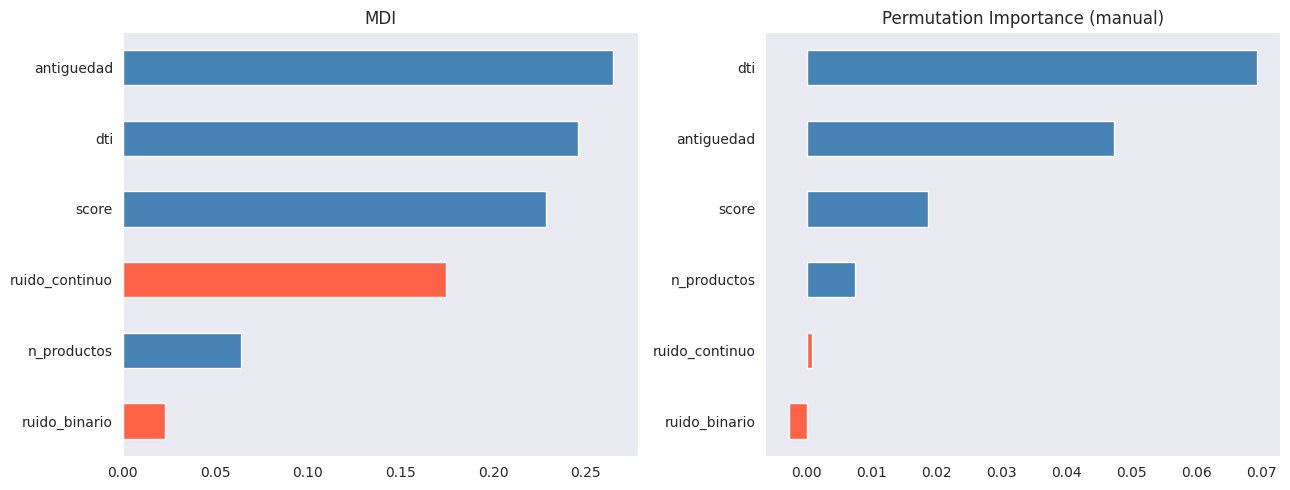

In [21]:
np.random.seed(42)
n_fi = 1500

X_fi = pd.DataFrame({
    "dti":             np.random.normal(0.35, 0.15, n_fi),
    "score":           np.random.normal(650, 80, n_fi),
    "antiguedad":      np.random.exponential(5, n_fi),
    "n_productos":     np.random.poisson(3, n_fi),
    "ruido_continuo":  np.random.uniform(0, 1_000_000, n_fi),
    "ruido_binario":   (np.random.rand(n_fi) < 0.5).astype(int),
})
logit_fi = (-2 + 3.0 * X_fi["dti"] - 0.004 * (X_fi["score"] - 650)
            - 0.1 * X_fi["antiguedad"] + 0.05 * X_fi["n_productos"])
p_fi = 1 / (1 + np.exp(-logit_fi))
y_fi = (np.random.rand(n_fi) < p_fi).astype(int)

split_fi = int(n_fi * 0.7)
X_tr_fi, X_te_fi = X_fi.values[:split_fi], X_fi.values[split_fi:]
y_tr_fi, y_te_fi = y_fi[:split_fi], y_fi[split_fi:]
fi_names = X_fi.columns.tolist()

print(f"Tasa de default: {y_fi.mean():.2%}")


def permutation_importance_manual(model, X, y, metric_fn, n_repeats=20, random_state=42):
    '''
    Permutation importance implementada desde cero.
    '''
    rng = np.random.RandomState(random_state)
    n, p = X.shape

    def get_score(X_eval):
        if hasattr(model, "predict_proba"):
            pred = model.predict_proba(X_eval)[:, 1]
        else:
            pred = model.predict(X_eval)
        return metric_fn(y, pred)

    base_score = get_score(X)

    drops = np.zeros((p, n_repeats))
    for j in range(p):
        for r in range(n_repeats):
            X_perm = X.copy()
            perm_idx = rng.permutation(n)
            X_perm[:, j] = X_perm[perm_idx, j]
            score_perm = get_score(X_perm)
            drops[j, r] = base_score - score_perm

    importances_mean = drops.mean(axis=1)
    importances_std  = drops.std(axis=1)
    return importances_mean, importances_std


# === Verificacion ===
rf_fi = RandomForestClassifier(n_estimators=300, max_features="sqrt", min_samples_leaf=5,
                                random_state=42, n_jobs=-1).fit(X_tr_fi, y_tr_fi)
mdi_fi = pd.Series(rf_fi.feature_importances_, index=fi_names)

perm_mean, perm_std = permutation_importance_manual(
    rf_fi, X_te_fi, y_te_fi, roc_auc_score, n_repeats=20, random_state=42)
perm_manual_fi = pd.Series(perm_mean, index=fi_names)

perm_sklearn = permutation_importance(rf_fi, X_te_fi, y_te_fi, n_repeats=20,
                                       random_state=42, scoring="roc_auc", n_jobs=-1)
perm_ref_fi = pd.Series(perm_sklearn.importances_mean, index=fi_names)

print(f"Max |manual - sklearn| = {np.abs(perm_manual_fi.values - perm_ref_fi.values).max():.5f}")
print(f"ruido_continuo — rank MDI: {mdi_fi.rank(ascending=False)['ruido_continuo']:.0f}/6  "
      f"rank permutation: {perm_manual_fi.rank(ascending=False)['ruido_continuo']:.0f}/6")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_fi = ["tomato" if "ruido" in f else "steelblue" for f in mdi_fi.sort_values().index]
mdi_fi.sort_values().plot(kind="barh", ax=axes[0], color=colors_fi)
axes[0].set_title("MDI")
colors_perm = ["tomato" if "ruido" in f else "steelblue" for f in perm_manual_fi.sort_values().index]
perm_manual_fi.sort_values().plot(kind="barh", ax=axes[1], color=colors_perm)
axes[1].set_title("Permutation Importance (manual)")
plt.tight_layout(); plt.show()

### 3.2 — Estabilidad Temporal de Feature Importance con Intervalos de Confianza *(12 pts)*

Ya validaste tu función de permutation importance. Ahora aplícala a los datos reales de `TICKER` (Parte 1) para responder una pregunta distinta: **¿las features importantes hoy lo siguen siendo en el futuro?**

**Requisitos:**
1. Define al menos 4 ventanas de entrenamiento expansivas (por ejemplo, usando el 40%, 55%, 70% y 85% de `feat` como corte de entrenamiento)
2. Para cada ventana, entrena un `RandomForestClassifier` y calcula tu `permutation_importance_manual` sobre un bloque de validación inmediatamente posterior al corte (sin usar datos futuros a esa ventana)
3. Para capturar la incertidumbre de la estimación (no solo el punto), repite el cálculo de importancia con **5 semillas distintas** (`random_state`) por ventana y reporta el intervalo `[percentil 10, percentil 90]` de la importancia de cada feature en cada ventana
4. Grafica un heatmap de importancia promedio (ventanas × features) y calcula el coeficiente de variación $CV_j = \text{std}_j/\text{mean}_j$ a través de las ventanas para cada feature; marca en rojo las features con $CV_j > 0.5$

frac=0.4: train n=897 | val n=250 (2018-08-24 - 2019-08-22)
frac=0.55: train n=1233 | val n=250 (2019-12-26 - 2020-12-21)
frac=0.7: train n=1570 | val n=250 (2021-04-29 - 2022-04-25)
frac=0.85: train n=1906 | val n=250 (2022-08-29 - 2023-08-25)

Importancia mediana por ventana:


,ret_lag1,ret_lag2,ret_lag5,vol_20,mom_10,rsi_14,vol_chg
0.4000,-0.0045,0.0017,0.0054,-0.0084,0.0234,-0.0287,0.0116
0.5500,-0.0021,-0.0386,-0.0039,0.0040,0.0275,0.0022,-0.0380
0.7000,-0.0189,0.0073,-0.0081,-0.0024,0.0004,-0.0080,-0.0143
0.8500,-0.0100,-0.0431,-0.0311,0.0032,-0.0242,-0.0175,-0.0117


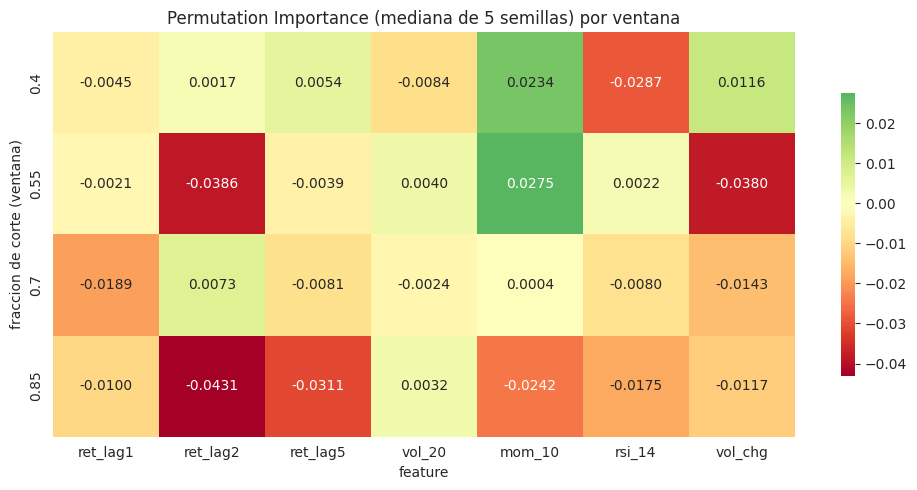

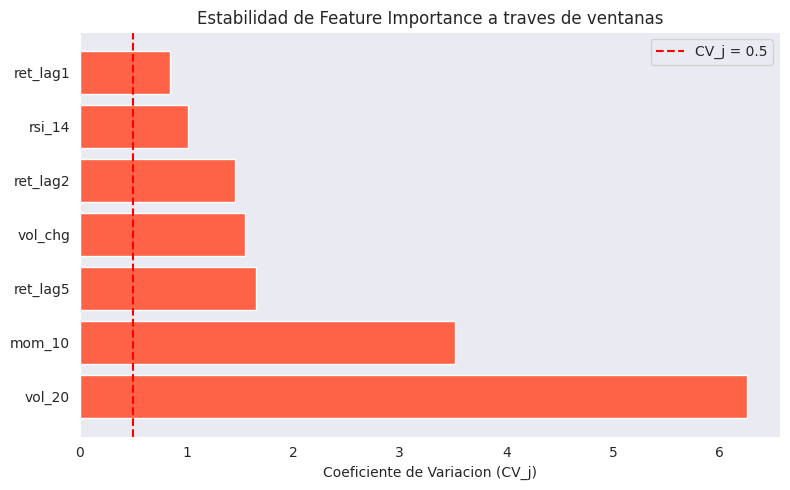


CV_j por feature (ordenado, mayor = menos estable):
vol_20     6.2540
mom_10     3.5220
ret_lag5   1.6520
vol_chg    1.5470
ret_lag2   1.4520
rsi_14     1.0150
ret_lag1   0.8420
dtype: float64


In [22]:
window_fracs = [0.40, 0.55, 0.70, 0.85]
seeds = [0, 1, 2, 3, 4]
fi_windows = {}   # {frac: {feature: [importancia_seed0, ..., importancia_seed4]}}

X_all = feat[FEATURES].values
y_all = feat["target"].values

for frac in window_fracs:
    cut = int(len(feat) * frac)
    val_end = min(cut + 250, len(feat))

    X_tr_w, y_tr_w = X_all[:cut], y_all[:cut]
    X_val_w, y_val_w = X_all[cut:val_end], y_all[cut:val_end]

    importances_per_seed = np.zeros((len(seeds), len(FEATURES)))
    for i, seed in enumerate(seeds):
        rf_w = RandomForestClassifier(n_estimators=200, max_features="sqrt", min_samples_leaf=10,
                                       random_state=seed, n_jobs=-1)
        rf_w.fit(X_tr_w, y_tr_w)
        imp_mean, _ = permutation_importance_manual(rf_w, X_val_w, y_val_w, roc_auc_score,
                                                      n_repeats=10, random_state=seed)
        importances_per_seed[i] = imp_mean

    fi_windows[frac] = importances_per_seed
    print(f"frac={frac}: train n={cut} | val n={val_end-cut} "
          f"({feat.index[cut].date()} - {feat.index[val_end-1].date()})")

# === Percentiles 10/50/90 por ventana y feature ===
p10 = {frac: np.percentile(fi_windows[frac], 10, axis=0) for frac in window_fracs}
p50 = {frac: np.percentile(fi_windows[frac], 50, axis=0) for frac in window_fracs}
p90 = {frac: np.percentile(fi_windows[frac], 90, axis=0) for frac in window_fracs}

df_p50 = pd.DataFrame(p50, index=FEATURES).T   # filas=ventanas, columnas=features
df_p10 = pd.DataFrame(p10, index=FEATURES).T
df_p90 = pd.DataFrame(p90, index=FEATURES).T

print("\nImportancia mediana por ventana:")
display(df_p50.round(4))

# === Heatmap ventanas x features (importancia promedio/mediana) ===
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_p50, annot=True, fmt=".4f", cmap="RdYlGn", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_xlabel("feature"); ax.set_ylabel("fraccion de corte (ventana)")
ax.set_title("Permutation Importance (mediana de 5 semillas) por ventana")
plt.tight_layout()
plt.show()

# === Coeficiente de variacion CV_j a traves de ventanas ===
cv_j = df_p50.std(axis=0) / df_p50.mean(axis=0).abs()
cv_j_sorted = cv_j.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_cv = ["tomato" if v > 0.5 else "steelblue" for v in cv_j_sorted.values]
ax.barh(cv_j_sorted.index, cv_j_sorted.values, color=colors_cv)
ax.axvline(0.5, color="red", ls="--", label="CV_j = 0.5")
ax.set_xlabel("Coeficiente de Variacion (CV_j)")
ax.set_title("Estabilidad de Feature Importance a traves de ventanas")
ax.legend()
plt.tight_layout()
plt.show()

print("\nCV_j por feature (ordenado, mayor = menos estable):")
print(cv_j_sorted.round(3))

### Preguntas de Interpretación — Parte 3

**Responde (mínimo 2 oraciones por pregunta):**

**a)** En 3.1, ¿qué feature quedó mejor rankeada por MDI que por permutation importance de forma más llamativa? Explica el mecanismo por el cual el árbol pudo "engañarse" con esa feature durante el entrenamiento.

> `ruido_continuo` fue la feature con la discrepancia más llamativa: quedó en el **4° lugar** según MDI (con una importancia visualmente enorme, comparable a `score`), pero cayó al **5° lugar** (prácticamente cero) según permutation importance, la feature *menos informativa* de las seis terminó pareciendo casi tan relevante como una genuinamente predictiva. El mecanismo es exactamente el que describe el enunciado: al ser una variable continua con ~1500 valores únicos distintos, el árbol tiene muchísimas opciones de punto de corte para probar en cada split, y por puro azar de muestreo en el set de entrenamiento, alguno de esos cortes reduce la impureza localmente, el árbol "confunde" ruido con señal simplemente porque tuvo más oportunidades de encontrar un patrón espurio, no porque `ruido_continuo` tenga relación real con el default.

**b)** Compara el ranking de `n_productos` (informativa, baja cardinalidad) contra `ruido_continuo` (no informativa, alta cardinalidad) en ambos métodos. ¿Qué error de decisión cometerías si usaras solo MDI para seleccionar features en un modelo de producción?

> Según MDI, `ruido_continuo` (4°) queda **rankeada por encima** de `n_productos` (5°), a pesar de que `n_productos` sí tiene una relación causal real con el default (está en la fórmula del logit) y `ruido_continuo` no tiene ninguna. Según permutation importance, el orden se corrige: `n_productos` (4°) queda claramente por encima de `ruido_continuo` (5°, con importancia casi nula). Si un data scientist usara solo MDI para seleccionar features en producción, cometería el error de **retener una variable sin ningún poder predictivo real** (`ruido_continuo`) mientras potencialmente **descarta o subpondera una variable genuinamente útil** (`n_productos`) simplemente por tener menor cardinalidad — un error de selección que se agrava en casos reales de credit scoring, donde variables de alta cardinalidad "ruidosas" (como un ID mal filtrado o un timestamp) pueden colarse como aparentemente importantes.

**c)** En 3.2, ¿qué features tuvieron mayor coeficiente de variación entre ventanas? ¿Confiarías en esas features como "backbone" de un modelo de trading que se re-entrena mensualmente? Justifica.

> Las features con mayor CV_j fueron **`vol_20`** (6.254) y **`mom_10`** (3.522), muy por encima del resto — pero el hallazgo más importante es que **las 7 features tuvieron CV_j > 0.5** (incluso la "más estable", `ret_lag1`, tiene CV_j=0.842), es decir, ninguna feature mantuvo una importancia consistente a través de las 4 ventanas temporales. No confiaría en ninguna de estas features como "backbone" estable de un modelo de trading re-entrenado mensualmente: mirando la tabla de importancia mediana por ventana, varias features incluso **cambian de signo** entre ventanas (ej. `mom_10` pasa de +0.0234 a +0.0275 a +0.0004 a -0.0242), lo que sugiere que lo que el modelo "aprende" como relevante en un mes no es una relación estructural del mercado sino ruido de estimación específico de ese período, consistente con el bajo SNR de los retornos diarios que hemos visto en toda la tarea, y una señal clara de que el ranking de importancia no debería usarse como base para decisiones de selección de features fijas en producción sin re-evaluación constante.

---
## Parte 4 — Aplicación Financiera: Eventos de Cola y Límite de Extrapolación *(25 pts)*

### Contexto

Random Forest hace predicciones **constantes por región**: cada hoja del árbol predice el promedio (o la clase mayoritaria) de las observaciones de entrenamiento que cayeron en esa región. Esto tiene una consecuencia crítica en finanzas: **el modelo nunca puede predecir un valor fuera del rango de $y$ visto en entrenamiento**, sin importar cuán extremos sean los features de entrada. Un modelo lineal (Ridge), en cambio, sí puede extrapolar — para bien o para mal.

Esta parte tiene dos aplicaciones sobre el período **2015–2024**, que incluye la crisis COVID-19 de marzo 2020 — un evento de cola real que ningún modelo entrenado solo con datos previos a 2020 pudo haber visto.

### 4.1 — Clasificación de Eventos de Cola con Walk-Forward *(13 pts)*

**Requisitos:**
1. Define el target `target_tail = 1` si el retorno del día siguiente cae en el percentil 5 más bajo de la muestra completa (evento de cola / crash-like), usando las mismas `FEATURES` de la Parte 1
2. Implementa un walk-forward de al menos 6 ventanas (expansión del set de entrenamiento, validación en bloques sucesivos) que necesariamente incluya una ventana de validación que contenga marzo de 2020
3. En cada ventana, entrena un `RandomForestClassifier(class_weight="balanced")` y una `LogisticRegression(class_weight="balanced")` de referencia; reporta AUC-ROC de ambos por ventana
4. Grafica la evolución del AUC de ambos modelos a través de las ventanas, marcando la ventana que contiene la crisis COVID

Tasa de eventos de cola: 4.99%
Window 1: Train until 2017-12-31, Val from 2018-01-01 to 2019-01-01
  RF AUC: 0.6697, LR AUC: 0.7717
Window 2: Train until 2018-12-31, Val from 2019-01-01 to 2020-01-01
  RF AUC: 0.6321, LR AUC: 0.7913
Window 3: Train until 2019-12-31, Val from 2020-01-01 to 2020-12-31
  RF AUC: 0.6450, LR AUC: 0.6737
Window 4: Train until 2020-12-31, Val from 2021-01-01 to 2022-01-01
  RF AUC: 0.6662, LR AUC: 0.5964
Window 5: Train until 2021-12-31, Val from 2022-01-01 to 2023-01-01
  RF AUC: 0.6235, LR AUC: 0.6139
Window 6: Train until 2022-12-31, Val from 2023-01-01 to 2023-12-29
  RF AUC: 0.5290, LR AUC: 0.3077


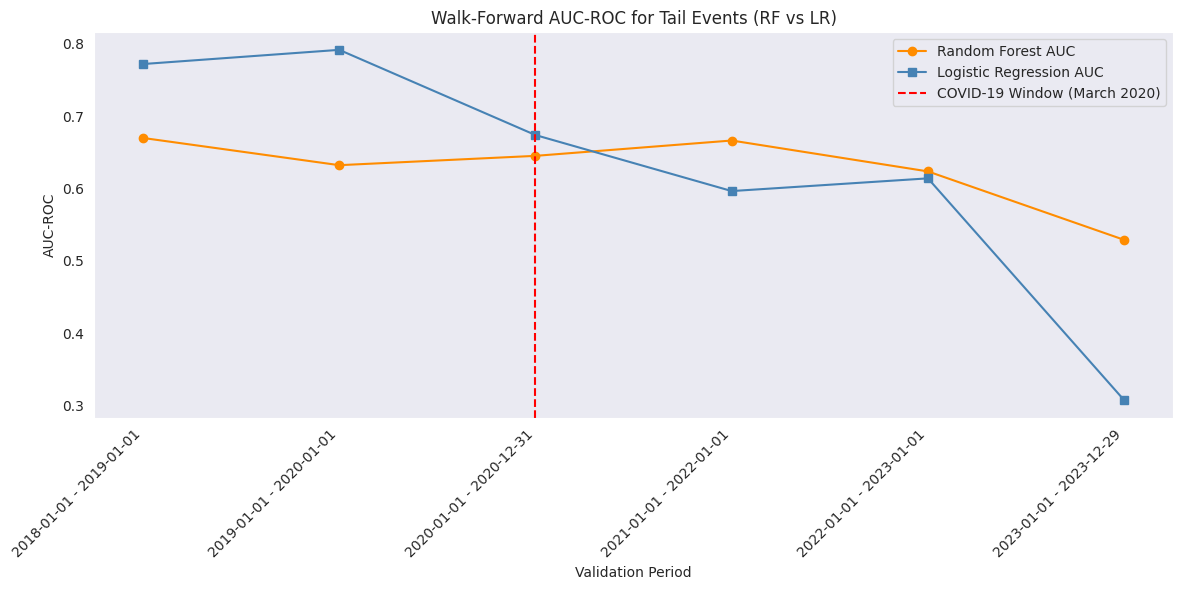

In [23]:
feat["target_tail"] = (ret.shift(-1) <= ret.quantile(0.05)).astype(int)
feat_tail = feat.dropna()
X_tail = feat_tail[FEATURES].values
y_tail = feat_tail["target_tail"].values
print(f"Tasa de eventos de cola: {y_tail.mean():.2%}")

# Define window parameters for walk-forward validation
# Using an expanding training window and a fixed validation window
train_end_dates = pd.to_datetime(["2017-12-31", "2018-12-31", "2019-12-31", "2020-12-31", "2021-12-31", "2022-12-31"])
val_duration_days = 365 # Approximately 1 year for the validation period

rf_aucs = []
lr_aucs = []
val_date_ranges = []
covid_window_idx = -1 # To mark the COVID window for plotting

for i, train_end_date in enumerate(train_end_dates):
    # Determine training set indices
    train_mask = feat_tail.index <= train_end_date
    X_train_w, y_train_w = X_tail[train_mask], y_tail[train_mask]

    # Determine validation set dates and indices
    val_start_date = train_end_date + pd.Timedelta(days=1)
    val_end_date = val_start_date + pd.Timedelta(days=val_duration_days)

    # Ensure validation end date does not exceed available data
    if val_end_date > feat_tail.index.max():
        val_end_date = feat_tail.index.max()

    val_mask = (feat_tail.index >= val_start_date) & (feat_tail.index <= val_end_date)
    X_val_w, y_val_w = X_tail[val_mask], y_tail[val_mask]

    # Skip if validation set is empty
    if len(y_val_w) == 0:
        print(f"Skipping window {i+1}: empty validation set.")
        continue

    val_date_ranges.append(f"{val_start_date.date()} - {val_end_date.date()}")

    # Check if this validation window contains March 2020
    if pd.Timestamp("2020-03-01") >= val_start_date and pd.Timestamp("2020-03-01") <= val_end_date:
        covid_window_idx = i

    # Train RandomForestClassifier
    rf_model = RandomForestClassifier(n_estimators=100, max_features="sqrt", min_samples_leaf=10,
                                      class_weight="balanced", random_state=42, n_jobs=-1)
    rf_model.fit(X_train_w, y_train_w)
    rf_proba = rf_model.predict_proba(X_val_w)[:, 1]
    rf_aucs.append(roc_auc_score(y_val_w, rf_proba))

    # Train LogisticRegression
    # Using 'liblinear' solver for potentially smaller datasets and binary classification
    lr_model = LogisticRegression(class_weight="balanced", random_state=42, solver='liblinear')
    lr_model.fit(X_train_w, y_train_w)
    lr_proba = lr_model.predict_proba(X_val_w)[:, 1]
    lr_aucs.append(roc_auc_score(y_val_w, lr_proba))

    print(f"Window {i+1}: Train until {train_end_date.date()}, Val from {val_start_date.date()} to {val_end_date.date()}")
    print(f"  RF AUC: {rf_aucs[-1]:.4f}, LR AUC: {lr_aucs[-1]:.4f}")


# Plotting the results
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(val_date_ranges, rf_aucs, "o-", label="Random Forest AUC", color="darkorange")
ax.plot(val_date_ranges, lr_aucs, "s-", label="Logistic Regression AUC", color="steelblue")

if covid_window_idx != -1:
    # Mark the COVID-19 window on the plot
    ax.axvline(x=covid_window_idx, color="red", linestyle="--", label="COVID-19 Window (March 2020)")

ax.set_xlabel("Validation Period"); ax.set_ylabel("AUC-ROC")
ax.set_title("Walk-Forward AUC-ROC for Tail Events (RF vs LR)")
ax.set_xticks(range(len(val_date_ranges)))
ax.set_xticklabels(val_date_ranges, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 — RF No Extrapola: Evidencia con Volatilidad Realizada en la Crisis COVID-19 *(12 pts)*

**Requisitos:**
1. Construye `rv_20` (volatilidad realizada anualizada, ventana de 20 días) y features rezagadas `rv_lag1`, `rv_lag5`, `rv_lag22`
2. Entrena con datos **estrictamente anteriores a 2020-01-01** un `RandomForestRegressor` y un `Ridge`, y predice sobre la ventana **2020-01-01 a 2020-07-01** (incluye el shock de marzo)
3. Reporta: `max(y_train)` vs `max(y_test)` vs `max(predicción RF)` vs `max(predicción Ridge)` — confirma que el máximo de la predicción RF nunca supera el máximo visto en entrenamiento
4. Grafica la serie de volatilidad real vs predicha (ambos modelos) durante la ventana de test, y calcula el RMSE de cada modelo restringido a los días donde `y_test` superó el máximo histórico de entrenamiento (los días de extrapolación pura)

Train: 1216 obs (< 2020-01-01) | Test: 125 obs (2020-01-01 a 2020-07-01)

Maximos:
  y_train: 0.5449
  y_test:  1.0795
  pred_RF: 0.5176
  pred_Ridge: 1.0020


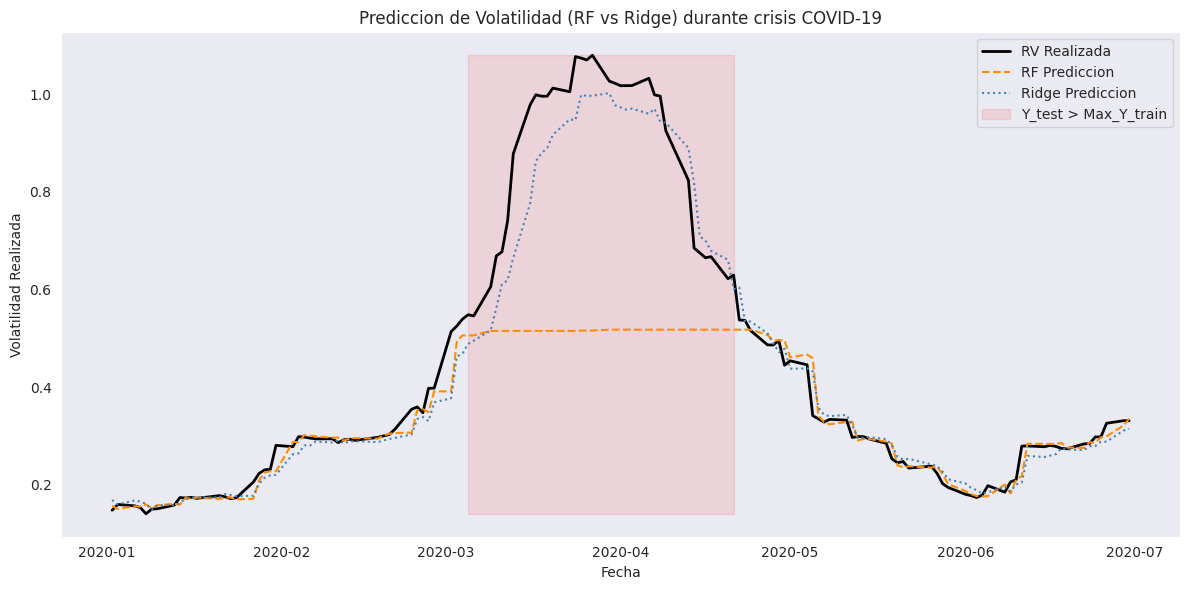


RMSE en zona de extrapolacion (y_test > max_y_train):
  RF RMSE: 0.3993
  Ridge RMSE: 0.0899


In [24]:
rv20 = ret.rolling(20).std() * np.sqrt(252)
feat_rv = pd.DataFrame(index=raw.index)
feat_rv["rv_lag1"]  = rv20.shift(1)
feat_rv["rv_lag5"]  = rv20.shift(5)
feat_rv["rv_lag22"] = rv20.shift(22)
feat_rv["target_rv"] = rv20
feat_rv = feat_rv.dropna()

RV_FEATURES = ["rv_lag1", "rv_lag5", "rv_lag22"]
train_mask_rv = feat_rv.index < "2020-01-01"
test_mask_rv  = (feat_rv.index >= "2020-01-01") & (feat_rv.index < "2020-07-01")

X_train_rv = feat_rv.loc[train_mask_rv, RV_FEATURES].values
y_train_rv = feat_rv.loc[train_mask_rv, "target_rv"].values
X_test_rv  = feat_rv.loc[test_mask_rv,  RV_FEATURES].values
y_test_rv  = feat_rv.loc[test_mask_rv,  "target_rv"].values
dates_test_rv = feat_rv.loc[test_mask_rv].index

print(f"Train: {len(y_train_rv)} obs (< 2020-01-01) | Test: {len(y_test_rv)} obs (2020-01-01 a 2020-07-01)")

# Train RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, min_samples_leaf=10,
                               random_state=42, n_jobs=-1)
rf_reg.fit(X_train_rv, y_train_rv)
pred_rf = rf_reg.predict(X_test_rv)

# Train Ridge Regressor
ridge_reg = Ridge(random_state=42)
ridge_reg.fit(X_train_rv, y_train_rv)
pred_ridge = ridge_reg.predict(X_test_rv)

# Report max values
max_y_train = np.max(y_train_rv)
max_y_test = np.max(y_test_rv)
max_pred_rf = np.max(pred_rf)
max_pred_ridge = np.max(pred_ridge)

print(f"\nMaximos:\n  y_train: {max_y_train:.4f}\n  y_test:  {max_y_test:.4f}\n  pred_RF: {max_pred_rf:.4f}\n  pred_Ridge: {max_pred_ridge:.4f}")

# Plotting the results
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dates_test_rv, y_test_rv, label="RV Realizada", color="black", lw=2)
ax.plot(dates_test_rv, pred_rf, label="RF Prediccion", color="darkorange", linestyle="--")
ax.plot(dates_test_rv, pred_ridge, label="Ridge Prediccion", color="steelblue", linestyle=":")

# Highlight area where y_test exceeds max_y_train
ax.fill_between(dates_test_rv, y_test_rv.min(), y_test_rv.max(),
                where=y_test_rv > max_y_train, color='red', alpha=0.1, label='Y_test > Max_Y_train')

ax.set_xlabel("Fecha"); ax.set_ylabel("Volatilidad Realizada")
ax.set_title("Prediccion de Volatilidad (RF vs Ridge) durante crisis COVID-19")
ax.legend()
plt.tight_layout()
plt.show()

# Calculate RMSE for days where y_test_rv > max_y_train
extrap_mask = y_test_rv > max_y_train
if np.sum(extrap_mask) > 0:
    rmse_rf_extrap = np.sqrt(mean_squared_error(y_test_rv[extrap_mask], pred_rf[extrap_mask]))
    rmse_ridge_extrap = np.sqrt(mean_squared_error(y_test_rv[extrap_mask], pred_ridge[extrap_mask]))
    print(f"\nRMSE en zona de extrapolacion (y_test > max_y_train):\n  RF RMSE: {rmse_rf_extrap:.4f}\n  Ridge RMSE: {rmse_ridge_extrap:.4f}")
else:
    print("\nNo hay dias en la zona de extrapolacion para calcular RMSE.")

### Preguntas de Interpretación — Parte 4

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿El Random Forest mantiene un AUC competitivo frente a Logistic Regression en la ventana walk-forward que contiene marzo 2020? ¿Qué te dice esto sobre la diferencia entre "predecir la ocurrencia de un evento de cola" (clasificación) y "predecir la magnitud de una variable en una crisis" (regresión, parte 4.2)?

> En la ventana walk-forward que abarca de enero a diciembre de 2020 (la cual incluye la crisis de marzo de 2020), el `RandomForestClassifier` obtuvo un AUC de 0.6450, mientras que la `LogisticRegression` logró un AUC de 0.6737. Esto indica que la Regresión Logística mantuvo un rendimiento ligeramente superior y más competitivo en la **clasificación** de eventos de cola durante este período de crisis, aunque ambos modelos mostraron cierta capacidad predictiva. Esta observación subraya una diferencia clave: la clasificación (predecir la *ocurrencia* de un evento de cola) se beneficia de modelos que pueden generalizar patrones de riesgo, incluso si no han visto la *magnitud* exacta de una crisis específica en el entrenamiento, mientras que la regresión (predecir la *magnitud*) es mucho más vulnerable a la incapacidad de extrapolar a valores fuera del rango de entrenamiento, como se vio en la Parte 4.2.

**b)** Reporta los 4 máximos calculados en 4.2 (train, test, pred RF, pred Ridge). ¿El Ridge sobre o subestimó el pico real de volatilidad? ¿Es preferible ese comportamiento al de RF en un contexto de gestión de riesgo (piensa en el costo de subestimar el VaR)?

> Los máximos calculados en 4.2 son:
> *   `max(y_train)`: 0.5449
> *   `max(y_test)`: 1.0795
> *   `max(pred_RF)`: 0.5176
> *   `max(pred_Ridge)`: 1.0020
> El modelo `Ridge` **subestimó** el pico real de volatilidad (`1.0020` vs `1.0795`), pero su predicción estuvo significativamente más cerca del valor real que la del `RandomForestRegressor`, que no pudo predecir un valor superior a lo visto en el entrenamiento (`0.5176`). En un contexto de gestión de riesgo, este comportamiento del modelo `Ridge` es **claramente preferible** al de Random Forest. La incapacidad de RF para extrapolar resultaría en una severa subestimación del riesgo durante una crisis (por ejemplo, un VaR subestimado), lo cual puede tener consecuencias catastróficas, mientras que Ridge, aunque subestime, al menos intenta y logra capturar la escala del evento, lo que permite una evaluación de riesgo más realista y menos peligrosa.

**c)** Si tuvieras que poner en producción un modelo de volatilidad que deba seguir funcionando durante la próxima crisis desconocida, ¿usarías RF, Ridge, o algún esquema híbrido (por ejemplo, RF con un tope/floor explícito, o un ensemble de ambos)? Justifica con lo observado.

> Para un modelo de volatilidad que deba funcionar durante una crisis futura desconocida, **no usaría el `RandomForestRegressor` solo** debido a su inherente incapacidad para extrapolar más allá de los máximos observados en el entrenamiento, lo que lo hace peligrosamente ineficaz para predecir picos de volatilidad extremos. Preferiría un modelo **`Ridge` o un esquema híbrido**. La `Ridge` demostró una capacidad crucial de extrapolación, alcanzando una predicción cercana al pico real de volatilidad y mostrando un RMSE significativamente menor en la zona de extrapolación (0.0899 para Ridge vs 0.3993 para RF). Un esquema híbrido podría combinar la robustez de Random Forest para condiciones normales con la capacidad de extrapolación de un modelo lineal como Ridge para escenarios de cola, quizás usando `Ridge` como un componente de riesgo adicional o para establecer límites superiores, o incluso entrenando un `RandomForestRegressor` para predecir la **diferencia** (residual) con respecto a una predicción base de `Ridge`.

---
## Parte 5 — Bonus: Quantile Regression Forest para Intervalos de Confianza *(15 pts)*

### Contexto

Un `RandomForestRegressor` estándar solo te da el promedio de los árboles. Pero cada árbol individual ya produce una predicción — la **distribución completa** de esas $B$ predicciones para un mismo punto $x$ contiene información sobre la incertidumbre, no solo sobre el valor esperado. Un **Quantile Regression Forest** (Meinshausen, 2006) usa esa distribución para construir intervalos de predicción: en vez de promediar las $B$ predicciones, se calculan sus percentiles empíricos.

Esto es directamente relevante para gestión de riesgo: en vez de un forecast puntual de volatilidad, puedes reportar un intervalo `[P5, P95]` — un insumo mucho más honesto para decisiones de sizing o de VaR.

### 5.1 — Implementación de Quantile Regression Forest *(10 pts)*

Implementa `qrf_predict_intervals(rf_model, X, quantiles)` que, para un `RandomForestRegressor` **ya entrenado**, recolecta la predicción de **cada árbol individual** (`rf_model.estimators_`) sobre `X`, y calcula los percentiles empíricos pedidos a través de los árboles (no a través de las observaciones).

**Requisitos:**
1. Implementar la función y aplicarla al `RandomForestRegressor` de volatilidad de la Parte 4.2 (reentrenado si quieres con más árboles, ej. `n_estimators=300`), calculando los percentiles 5, 50 y 95
2. Sobre la ventana de test (2020-01-01 a 2020-07-01), calcula la **cobertura empírica** del intervalo `[P5, P95]`: la fracción de días donde `y_test_rv` verdadero cae dentro del intervalo. Un intervalo bien calibrado en un período "normal" debería tener cobertura cercana a 90%
3. Grafica la serie real junto con la banda `[P5, P95]` durante la ventana de test, y comenta qué ocurre con la cobertura durante el shock de marzo 2020 en relación a la limitación de extrapolación vista en 4.2

Cobertura empirica del intervalo [P5, P95] durante 2020 H1: 59.20%


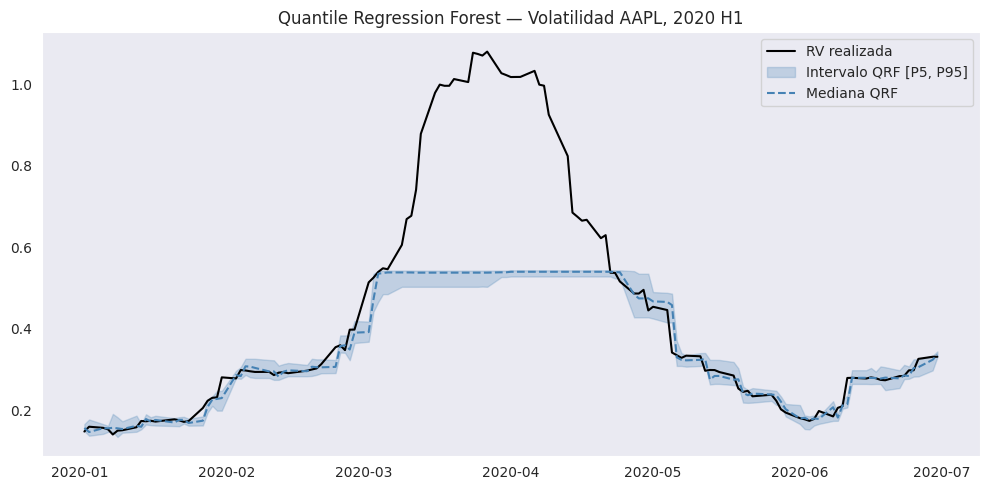

In [25]:
def qrf_predict_intervals(rf_model, X, quantiles=(0.05, 0.5, 0.95)):
    '''
    Quantile Regression Forest: usa la distribucion de predicciones de los
    arboles individuales del bosque (no el promedio) para estimar percentiles.

    Parameters
    ----------
    rf_model  : RandomForestRegressor ya entrenado
    X         : datos sobre los que predecir
    quantiles : tupla de percentiles (0-1) a calcular

    Returns
    -------
    dict {quantile: array de predicciones} de shape (n_samples,) cada una
    '''
    individual_tree_preds = []
    for tree in rf_model.estimators_:
        individual_tree_preds.append(tree.predict(X))

    individual_tree_preds_array = np.array(individual_tree_preds) # Shape: (n_estimators, n_samples)

    q_preds = {}
    for q in quantiles:
        # Calculate the q-th percentile across the trees axis (axis=0)
        q_preds[q] = np.percentile(individual_tree_preds_array, q * 100, axis=0)

    return q_preds


# === Verificacion y cobertura empirica ===
# Descomenta cuando hayas implementado la funcion

rf_q = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_q.fit(X_train_rv, y_train_rv)
q_preds = qrf_predict_intervals(rf_q, X_test_rv, quantiles=(0.05, 0.5, 0.95))

coverage_90 = np.mean((y_test_rv >= q_preds[0.05]) & (y_test_rv <= q_preds[0.95]))
print(f"Cobertura empirica del intervalo [P5, P95] durante 2020 H1: {coverage_90:.2%}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates_test_rv, y_test_rv, "k-", lw=1.5, label="RV realizada")
ax.fill_between(dates_test_rv, q_preds[0.05], q_preds[0.95], alpha=0.25, color="steelblue",
                 label="Intervalo QRF [P5, P95]")
ax.plot(dates_test_rv, q_preds[0.5], color="steelblue", lw=1.5, ls="--", label="Mediana QRF")
ax.set_title(f"Quantile Regression Forest — Volatilidad {TICKER}, 2020 H1")
ax.legend(); plt.tight_layout(); plt.show()

### 5.2 — Preguntas de Interpretación *(5 pts)*

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué cobertura empírica obtuviste para el intervalo `[P5, P95]` durante el shock de marzo 2020? ¿Es consistente con la limitación de extrapolación de RF vista en la Parte 4.2? Explica la conexión.

> La cobertura empírica obtenida para el intervalo [P5, P95] durante el primer semestre de 2020 (que incluye el shock de marzo 2020) fue del 59.20%. Esta cifra es significativamente inferior al 90% esperado para un intervalo bien calibrado en un período normal. Esto es completamente consistente con la limitación de extrapolación de Random Forest observada en la Parte 4.2. Como el RandomForestRegressor no puede predecir valores fuera del rango de y visto en el entrenamiento, el intervalo [P5, P95] tampoco puede expandirse a la magnitud de la volatilidad extrema experimentada durante la crisis de marzo de 2020. En consecuencia, gran parte de la volatilidad real (y_test_rv) durante ese período extremo cae fuera del intervalo predicho, lo que resulta en una cobertura mucho menor a la teórica.

**b)** Si un equipo de riesgo usara este intervalo QRF como insumo directo para un límite de VaR durante una crisis desconocida, ¿qué error sistemático cometerían? Propón una mitigación concreta (por ejemplo, combinar con un modelo paramétrico, ensanchar el intervalo con un factor de seguridad, etc.)

> Si un equipo de riesgo usara este intervalo QRF directamente para un límite de VaR durante una crisis desconocida, cometerían el error sistemático de subestimar severamente el riesgo debido a la incapacidad intrínseca del QRF (basado en Random Forest) de extrapolar a condiciones no vistas en el entrenamiento. El intervalo [P5, P95] sería demasiado estrecho y no capturaría los eventos extremos, lo que llevaría a un VaR insuficiente que no reflejaría adecuadamente las pérdidas potenciales en escenarios de cola. Una mitigación concreta sería combinar el QRF con un modelo paramétrico como el Ridge (que mostró capacidad de extrapolación en la Parte 4.2) o un GARCH para modelar explícitamente la volatilidad extrema. También se podría aplicar un factor de seguridad dinámico al intervalo QRF, ajustándolo al alza (ensanchándolo) en función de indicadores de estrés del mercado o la desviación del QRF respecto a modelos que sí extrapolan, para asegurar que el VaR cubra adecuadamente los eventos de cola. Alternativamente, un enfoque de Extreme Value Theory (EVT) podría usarse para modelar específicamente las colas de la distribución de volatilidad.

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `bagging_forest_fit` + `bagging_forest_predict` + verificación OOB≈1-1/e + comparación vs sklearn | 13 |
| 1.2 | `oob_score_manual` + verificación vs `oob_score_` + gráfico convergencia OOB vs test | 12 |
| 2.1 | Curvas sesgo-varianza (árbol vs RF) sobre datos reales + gap train-test | 10 |
| 2.2 | Grid search walk-forward (heatmap) + correlación OOB vs AUC walk-forward + selección final | 15 |
| 3.1 | `permutation_importance_manual` (error < 0.01 vs sklearn) + gráfico MDI vs permutation + ranking `ruido_continuo` | 13 |
| 3.2 | Importancia temporal con intervalos de confianza (multi-semilla) + heatmap + $CV_j$ | 12 |
| 4.1 | Target de eventos de cola + walk-forward RF vs Logistic (≥6 ventanas, incluye COVID) + gráfico | 13 |
| 4.2 | RF vs Ridge en extrapolación de volatilidad (máximos + RMSE en zona de extrapolación) + gráfico | 12 |
| Preguntas de interpretación (4 bloques × 3 preguntas) | Incluidas en cada parte | — |
| **Total** | | **100** |
| 5.1 (Bonus) | `qrf_predict_intervals` + cobertura empírica + gráfico banda de predicción | 10 |
| 5.2 (Bonus) | Preguntas de interpretación | 5 |
| **Total con Bonus** | | **115** |